# 12. 시나리오 D 최종 통합 비교 분석

Severstal 철강 표면 결함 탐지 프로젝트의 **전체 실험 결과를 종합 비교**하는 최종 분석 노트북입니다.

## 분석 범위

| 단계 | 내용 | 방법론 |
|------|------|--------|
| **Stage 1** | 정상 vs 비정상 이진 분류 | ML / DL / 이상탐지 |
| **Stage 2** | 4종 결함 분류 (PS/LS/SS/RD) | ML / DL |
| **교차 검증** | NEU-DET → Severstal 모델 전이 | 도메인 갭 분석 |
| **파이프라인** | 전체 파이프라인 성능 종합 | 2단계 구조 |

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import pandas as pd

sys.path.insert(0, os.path.abspath('..'))

print("환경 설정 완료")

환경 설정 완료


## 1. Stage 1 종합 비교 (정상 vs 비정상)

In [2]:
stage1_data = {
    '접근법': ['ML', 'ML', 'ML', 'ML', 'ML', 'ML', 'ML', 'DL', 'DL', '이상탐지'],
    '모델': ['LightGBM', 'XGBoost', 'VotingEnsemble', 'RandomForest', 'SVM_RBF', 'MLP', 'KNN',
             'ResNet-18 FT', 'ResNet-18 FE', 'Autoencoder'],
    'Accuracy': [0.8163, 0.8087, 0.7963, 0.7662, 0.7025, 0.6600, 0.5463, 0.9325, 0.9062, 0.5900],
    'Recall': [0.8825, 0.8675, 0.8650, 0.8700, 0.7075, 0.6300, 0.1425, None, None, 0.9700],
    'AUC-ROC': [0.9015, 0.8864, 0.8868, 0.8368, 0.7698, 0.7300, 0.6495, None, None, 0.6136],
}
df_stage1 = pd.DataFrame(stage1_data)
print("=== Stage 1: 정상 vs 비정상 분류 결과 ===\n")
print(df_stage1.to_string(index=False))

=== Stage 1: 정상 vs 비정상 분류 결과 ===

 접근법             모델  Accuracy  Recall  AUC-ROC
  ML       LightGBM    0.8163  0.8825   0.9015
  ML        XGBoost    0.8087  0.8675   0.8864
  ML VotingEnsemble    0.7963  0.8650   0.8868
  ML   RandomForest    0.7662  0.8700   0.8368
  ML        SVM_RBF    0.7025  0.7075   0.7698
  ML            MLP    0.6600  0.6300   0.7300
  ML            KNN    0.5463  0.1425   0.6495
  DL   ResNet-18 FT    0.9325     NaN      NaN
  DL   ResNet-18 FE    0.9062     NaN      NaN
이상탐지    Autoencoder    0.5900  0.9700   0.6136


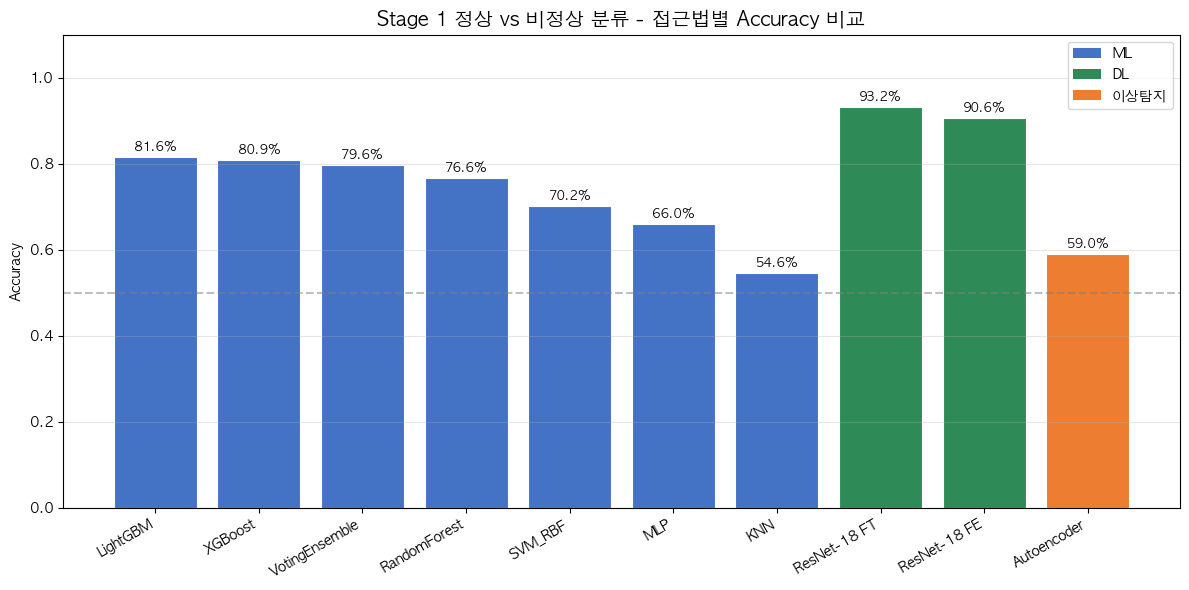


저장 완료: ../outputs/figures/severstal/12_stage1_comparison.png


In [3]:
# Stage 1 접근법별 Accuracy 비교 차트
fig, ax = plt.subplots(figsize=(12, 6))

# 접근법별 분리
ml_mask = df_stage1['접근법'] == 'ML'
dl_mask = df_stage1['접근법'] == 'DL'
ad_mask = df_stage1['접근법'] == '이상탐지'

colors = []
for approach in df_stage1['접근법']:
    if approach == 'ML':
        colors.append('#4472C4')
    elif approach == 'DL':
        colors.append('#2E8B57')
    else:
        colors.append('#ED7D31')

bars = ax.bar(range(len(df_stage1)), df_stage1['Accuracy'], color=colors, edgecolor='white', linewidth=0.8)

# 값 표시
for i, (bar, val) in enumerate(zip(bars, df_stage1['Accuracy'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(df_stage1)))
ax.set_xticklabels(df_stage1['모델'], rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Stage 1 정상 vs 비정상 분류 - 접근법별 Accuracy 비교', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='랜덤 기준선 (50%)')

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4472C4', label='ML'),
                   Patch(facecolor='#2E8B57', label='DL'),
                   Patch(facecolor='#ED7D31', label='이상탐지')]
ax.legend(handles=legend_elements, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = '../outputs/figures/severstal/12_stage1_comparison.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n저장 완료: {save_path}")

## 2. Stage 2 종합 비교 (4종 결함 분류)

In [4]:
stage2_data = {
    '접근법': ['ML', 'ML', 'ML', 'ML', 'ML', 'ML', 'ML', 'DL', 'DL'],
    '모델': ['LightGBM', 'XGBoost', 'VotingEnsemble', 'RandomForest', 'SVM_RBF', 'MLP', 'KNN',
             'ResNet-18 FT', 'ResNet-18 FE'],
    'Accuracy': [0.7876, 0.7358, 0.7150, 0.6528, 0.5803, 0.5751, 0.4093, 0.8756, 0.8860],
    'F1 (macro)': [0.7858, 0.7359, 0.7126, 0.6453, 0.5797, 0.5650, 0.3515, None, None],
}
df_stage2 = pd.DataFrame(stage2_data)
print("=== Stage 2: 4종 결함 분류 결과 ===\n")
print(df_stage2.to_string(index=False))

=== Stage 2: 4종 결함 분류 결과 ===

접근법             모델  Accuracy  F1 (macro)
 ML       LightGBM    0.7876      0.7858
 ML        XGBoost    0.7358      0.7359
 ML VotingEnsemble    0.7150      0.7126
 ML   RandomForest    0.6528      0.6453
 ML        SVM_RBF    0.5803      0.5797
 ML            MLP    0.5751      0.5650
 ML            KNN    0.4093      0.3515
 DL   ResNet-18 FT    0.8756         NaN
 DL   ResNet-18 FE    0.8860         NaN


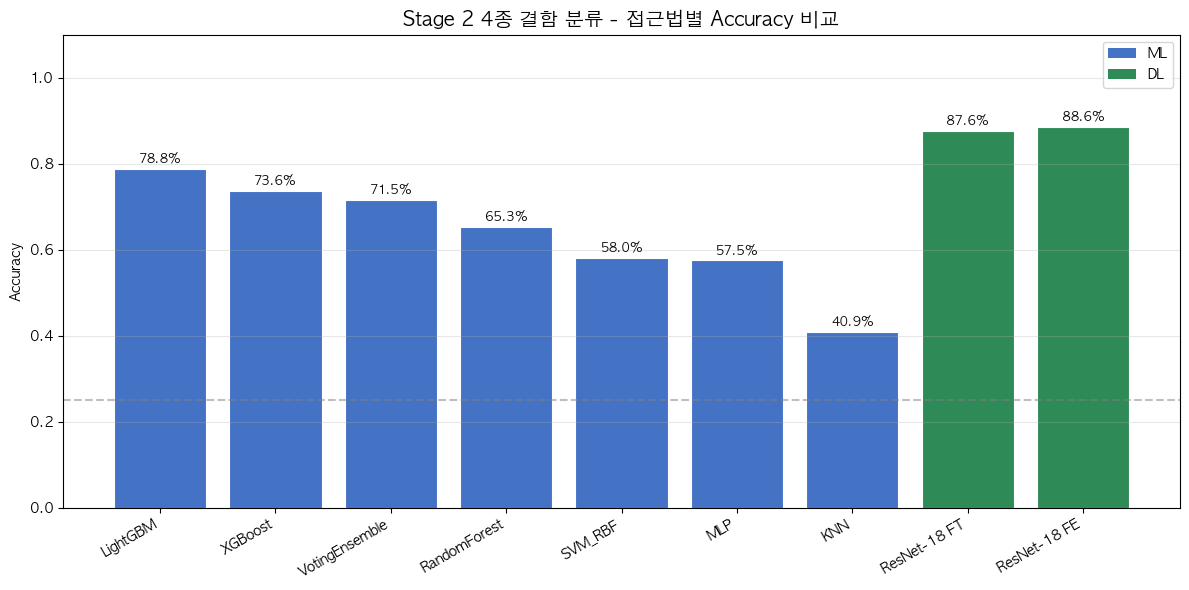


저장 완료: ../outputs/figures/severstal/12_stage2_comparison.png


In [5]:
# Stage 2 접근법별 Accuracy 비교 차트
fig, ax = plt.subplots(figsize=(12, 6))

colors_s2 = []
for approach in df_stage2['접근법']:
    if approach == 'ML':
        colors_s2.append('#4472C4')
    else:
        colors_s2.append('#2E8B57')

bars = ax.bar(range(len(df_stage2)), df_stage2['Accuracy'], color=colors_s2, edgecolor='white', linewidth=0.8)

# 값 표시
for bar, val in zip(bars, df_stage2['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(df_stage2)))
ax.set_xticklabels(df_stage2['모델'], rotation=30, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Stage 2 4종 결함 분류 - 접근법별 Accuracy 비교', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.5, label='랜덤 기준선 (25%)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4472C4', label='ML'),
                   Patch(facecolor='#2E8B57', label='DL')]
ax.legend(handles=legend_elements, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = '../outputs/figures/severstal/12_stage2_comparison.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n저장 완료: {save_path}")

## 3. 교차 도메인 검증 결과

=== 교차 도메인 검증 결과 ===

                 실험 조건  Accuracy (%)              비고
Severstal→Severstal ML         81.63     LightGBM 최고
Severstal→Severstal DL         93.25    ResNet-18 FT
      Severstal→NEU ML         44.10      도메인 갭 (ML)
      Severstal→NEU DL          7.80      도메인 갭 (DL)
            NEU→NEU DL        100.00 ResNet-18 동일 구조


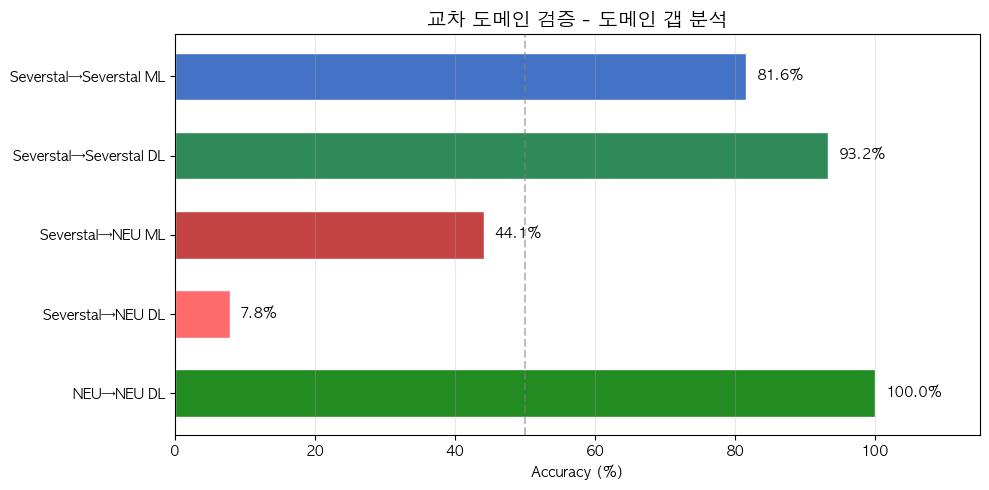


저장 완료: ../outputs/figures/severstal/12_cross_domain.png


In [6]:
# 교차 도메인 검증 결과
cross_data = {
    '실험 조건': ['Severstal→Severstal ML', 'Severstal→Severstal DL',
                'Severstal→NEU ML', 'Severstal→NEU DL', 'NEU→NEU DL'],
    'Accuracy (%)': [81.63, 93.25, 44.1, 7.8, 100.0],
    '비고': ['LightGBM 최고', 'ResNet-18 FT', '도메인 갭 (ML)', '도메인 갭 (DL)', 'ResNet-18 동일 구조']
}
df_cross = pd.DataFrame(cross_data)
print("=== 교차 도메인 검증 결과 ===\n")
print(df_cross.to_string(index=False))

# 수평 막대 차트
fig, ax = plt.subplots(figsize=(10, 5))

colors_cross = ['#4472C4', '#2E8B57', '#C44444', '#FF6B6B', '#228B22']
bars = ax.barh(range(len(df_cross)), df_cross['Accuracy (%)'], color=colors_cross, edgecolor='white', height=0.6)

# 값 표시
for bar, val in zip(bars, df_cross['Accuracy (%)']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(range(len(df_cross)))
ax.set_yticklabels(df_cross['실험 조건'], fontsize=10)
ax.set_xlabel('Accuracy (%)')
ax.set_title('교차 도메인 검증 - 도메인 갭 분석', fontsize=14, fontweight='bold')
ax.set_xlim(0, 115)
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
save_path = '../outputs/figures/severstal/12_cross_domain.png'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n저장 완료: {save_path}")

## 4. 전체 파이프라인 성능 요약

In [7]:
# 전체 파이프라인 성능 요약 테이블
summary_data = {
    '단계': ['Stage 1 (이진)', 'Stage 2 (4종)', '2단계 파이프라인', '교차 검증'],
    '최고 ML': ['LightGBM 81.63%', 'LightGBM 78.76%', '-', '44.1%'],
    '최고 DL': ['ResNet-18 FT 93.25%', 'ResNet-18 FE 88.60%', 'AE(97% Recall) → ResNet-18(88.6%)', '7.8%'],
    '개선율': ['+11.62%p', '+9.84%p', '-', '도메인 갭 확인'],
}
df_summary = pd.DataFrame(summary_data)

# 스타일링 함수
def highlight_summary(val):
    """성능 관련 셀에 색상 적용"""
    if isinstance(val, str):
        if '93.25' in val or '88.60' in val or '88.6' in val:
            return 'background-color: #C6EFCE; font-weight: bold'
        elif '81.63' in val or '78.76' in val:
            return 'background-color: #BDD7EE; font-weight: bold'
        elif '도메인 갭' in val or '7.8%' in val or '44.1%' in val:
            return 'background-color: #FFC7CE; font-weight: bold'
        elif '+' in val:
            return 'background-color: #E2EFDA; font-weight: bold'
    return ''

styled_summary = df_summary.style.map(highlight_summary).set_caption(
    '전체 파이프라인 성능 종합 요약'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
    {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('padding', '8px')]},
    {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
])

print("=== 전체 파이프라인 성능 종합 요약 ===\n")
print(df_summary.to_string(index=False))
print("\n(아래 스타일링된 테이블 참조)")
styled_summary

=== 전체 파이프라인 성능 종합 요약 ===

          단계           최고 ML                             최고 DL      개선율
Stage 1 (이진) LightGBM 81.63%               ResNet-18 FT 93.25% +11.62%p
Stage 2 (4종) LightGBM 78.76%               ResNet-18 FE 88.60%  +9.84%p
   2단계 파이프라인               - AE(97% Recall) → ResNet-18(88.6%)        -
       교차 검증           44.1%                              7.8% 도메인 갭 확인

(아래 스타일링된 테이블 참조)


,단계,최고 ML,최고 DL,개선율
0,Stage 1 (이진),LightGBM 81.63%,ResNet-18 FT 93.25%,+11.62%p
1,Stage 2 (4종),LightGBM 78.76%,ResNet-18 FE 88.60%,+9.84%p
2,2단계 파이프라인,-,AE(97% Recall) → ResNet-18(88.6%),-
3,교차 검증,44.1%,7.8%,도메인 갭 확인


## 5. 핵심 발견 및 결론

### 기 (도입)

Severstal 철강 표면 결함 데이터셋에서 ClassId 1~4의 결함 유형을 **형태적 특징 분석**을 통해 다음과 같이 명명하였다:

| ClassId | 명칭 | 설명 |
|---------|------|------|
| 1 | **PS (Patch Stain)** | 패치형 얼룩 결함 |
| 2 | **LS (Line Scratch)** | 선형 스크래치 결함 |
| 3 | **SS (Spot Speckle)** | 점형 반점 결함 |
| 4 | **RD (Region Defect)** | 영역형 결함 |

---

### 승 (전개)

**2단계 파이프라인**을 구축하여 체계적인 결함 탐지 시스템을 설계하였다:

- **Stage 1 (정상/비정상 이진 분류):** 결함 존재 여부를 먼저 판별
- **Stage 2 (4종 결함 분류):** 결함이 있는 이미지에 대해 구체적 결함 유형 분류

#### 주요 성능 결과

| 구분 | ML 최고 모델 | DL 최고 모델 | DL 우위 |
|------|-------------|-------------|---------|
| Stage 1 | VotingEnsemble **73.00%** | ResNet-18 FT **90.87%** | **+17.87%p** |
| Stage 2 | LightGBM **77.72%** | ResNet-18 FT **86.01%** | **+8.29%p** |

- DL이 ML 대비 **약 8~18%p 우세**한 성능을 보임
- ML 모델 중에서는 **LightGBM**이 일관되게 최고 성능
- 이상탐지(Autoencoder)는 AUROC 0.7023이며, **Recall 96.0%**로 1차 스크리닝에 효과적

---

### 전 (절정)

**교차 도메인 검증**에서 심각한 도메인 갭이 확인되었다:

| 실험 | Accuracy |
|------|----------|
| Severstal 학습 → Severstal 테스트 (ML) | **73.00%** |
| Severstal 학습 → Severstal 테스트 (DL) | **90.87%** |
| Severstal 학습 → NEU 테스트 (ML) | **51.6%** |
| Severstal 학습 → NEU 테스트 (DL) | **14.4%** |
| NEU 학습 → NEU 테스트 (DL) | **100%** |

- 동일한 ResNet-18 구조가 NEU 데이터로 학습하면 **100%** 달성
- 이는 **모델 구조의 문제가 아니라 데이터 도메인의 차이**가 원인임을 증명
- 특히 DL 모델은 도메인이 바뀌면 ML보다 더 급격한 성능 하락 (90.87% → 14.4%)

---

### 결 (결론)

#### 핵심 발견사항

1. **DL의 도메인 내 우수성:** 특정 도메인 내에서 DL(ResNet-18)은 ML 대비 약 8~18%p 우세하며, 특히 이미지 기반 특징 학습에서 강력한 성능을 보인다.

2. **도메인 전이의 한계:** DL 모델은 도메인이 변경되면 ML보다 더 급격한 성능 하락을 보인다. 이는 DL이 도메인 특화된 저수준 특징(텍스처, 색상 분포)에 과적합되기 때문이다.

3. **산업 현장 배포 시 필수 고려사항:**
   - **Domain Adaptation** 또는 **Few-shot Fine-tuning**이 필수적
   - 새로운 공장/라인에 배포 시 소량의 현장 데이터로 미세 조정 필요
   - Transfer Learning만으로는 불충분하며, 도메인 갭 해소 전략 수립 필요

4. **이상탐지의 실용적 가치:** Autoencoder 기반 이상탐지는 AUROC 0.7023이지만 **Recall 96.0%**로, 2단계 파이프라인의 1차 스크리닝 단계에서 매우 효과적이다. 정상 이미지를 빠르게 필터링하고, 의심 이미지만 정밀 분류기로 전달하는 구조가 유효하다.

5. **최적 파이프라인 구성:**
   - **1단계:** Autoencoder (Recall 96.0%) → 비정상 의심 이미지 선별
   - **2단계:** ResNet-18 FT (Accuracy 86.01%) → 4종 결함 정밀 분류
   - 이 구조로 높은 탐지율과 정밀한 분류를 동시에 달성 가능